In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"] = housing.target

In [5]:
x = data[["AveRooms"]].values
y = data[["Price"]].values

In [6]:
X_train, X_test,y_train,y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
w = 0
b = 0
learning_rate = 0.01
epochs = 1000
cost_history = []
n = len(X_train_scaled)

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b

    dw = (1/n) * np.sum((y_pred - y_train.flatten()) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train.flatten())

    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Compute cost
    cost = (1/(2*n)) * np.sum((y_pred - y_train.flatten())**2)

    # Store cost
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

y_pred_gd = w * X_test_scaled.flatten() + b
    

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [17]:
print("Gradient descent")
print("------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))


Gradient descent
------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [18]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta


In [19]:
print("\nNormal Equation")
print("---------------")
print("Intercept:",theta[0])
print("Slope",theta[1])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal Equation
---------------
Intercept: [1.65476227]
Slope [0.07675559]
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


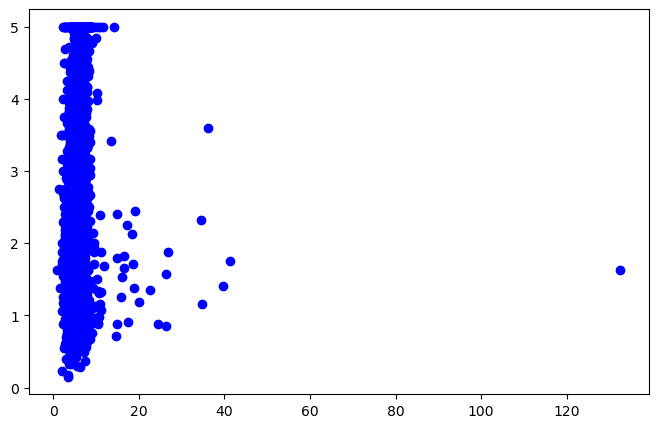

In [20]:
#Regression Line Visualization
#sort X values for a smooth line
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
#scatter plot
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

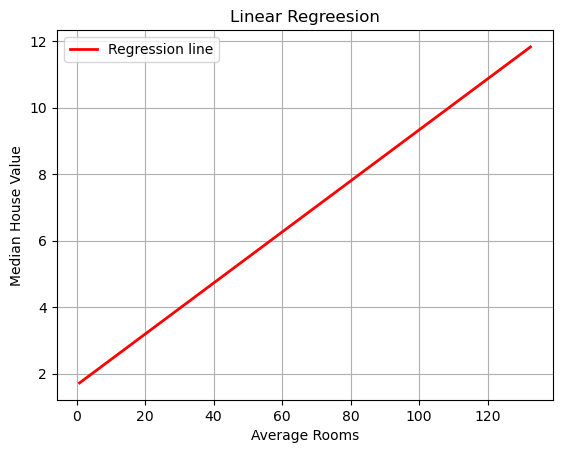

In [21]:
#REGRESSION lINE
plt.plot(
   X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression line'
)
plt.title("Linear Regreesion")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()
           

<function matplotlib.pyplot.show(close=None, block=None)>

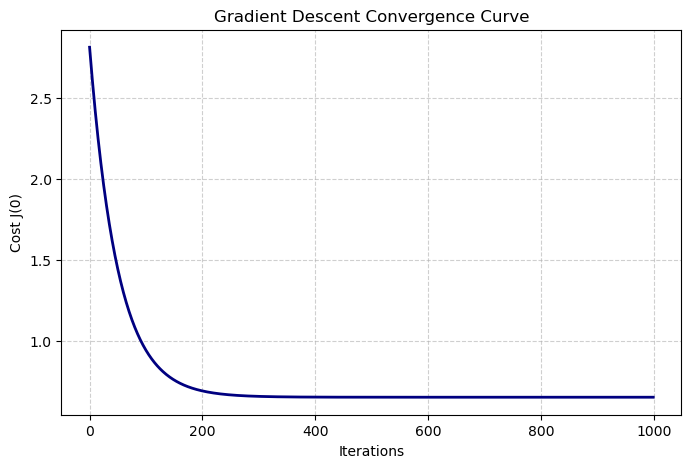

In [23]:
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='navy', linewidth=2)
plt.title('Gradient Descent Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(0)')
plt.grid(True,linestyle='--', alpha=0.6)

plt.show